<a href="https://colab.research.google.com/github/jeolin/chemCode/blob/main/activities/spectrophotometry_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Initialization Code Block

This code block sets up the necessary environment for the notebook by loading essential libraries like `numpy` and `matplotlib`, and configuring third-party widgets for interactive plots.

**Important:** Please run this cell **once** at the start of your session. You should re-run it if you:
*   Restart the Colab runtime.
*   Encounter network/Wi-Fi connectivity issues.
*   Are restarting the activity.

Running it multiple times generally won't cause problems, but it's only truly necessary once per fresh session to ensure all dependencies are correctly loaded and configured.

In [59]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

# Helper Functions and Variables for Plot Management
MAX_OPEN_FIGURES = 5
_active_figures = []

def _manage_figures():
    global _active_figures
    # Close oldest figures if we exceed the limit
    while len(_active_figures) >= MAX_OPEN_FIGURES:
        fig_to_close = _active_figures.pop(0) # Remove oldest figure reference
        plt.close(fig_to_close)

# Data Definitions
compound_names_map = {
    "1": "Tartrazine",
    "2": "Copper Sulfate",
    "3": "Potassium Permanganate",
    "4": "Cobalt Chloride",
    "5": "Nickel Sulfate"
}

# Define visible spectrum colors and their corresponding wavelengths (for plotting)
# These are approximate values for a qualitative visual representation
COLORS_VISIBLE_SPECTRUM = [
    (0.25, 0.0, 0.5), # Violet (~400 nm)
    (0.0, 0.0, 1.0),  # Blue (~475 nm)
    (0.0, 1.0, 0.0),  # Green (~525 nm)
    (1.0, 1.0, 0.0),  # Yellow (~570 nm)
    (1.0, 0.5, 0.0),  # Orange (~600 nm)
    (1.0, 0.0, 0.0)   # Red (~650 nm)
]
CMAP_NAME_VISIBLE_SPECTRUM = 'VisibleSpectrum'
CMP_VISIBLE_SPECTRUM = mcolors.LinearSegmentedColormap.from_list(CMAP_NAME_VISIBLE_SPECTRUM, COLORS_VISIBLE_SPECTRUM)

# Definition of the generate_spectrum function
def generate_spectrum(compound_id):
    # Define parameters for each compound's synthetic spectrum
    # These are illustrative and designed to meet the specified lambda_max ranges
    compounds_data = {
        1: {'name': 'Tartrazine', 'lambda_max': random.uniform(421, 429), 'fwhm': 50, 'amplitude': 0.8},
        2: {'name': 'Copper(II) Sulfate', 'lambda_max': random.uniform(596,604), 'fwhm': 80, 'amplitude': 0.6},
        3: {'name': 'Potassium Permanganate', 'lambda_max': random.uniform(521,529), 'fwhm': 60, 'amplitude': 0.9},
        4: {'name': 'Cobalt(II) Chloride', 'lambda_max': random.uniform(506,514), 'fwhm': 70, 'amplitude': 0.5},
        5: {'name': 'Nickel(II) Sulfate', 'lambda_max': random.uniform(716,724), 'fwhm': 90, 'amplitude': 0.7}  # Corrected compound name
    }

    if compound_id not in compounds_data:
        raise ValueError("Invalid compound_id. Choose between 1 and 5.")

    data = compounds_data[compound_id]
    compound_name = data['name']
    lambda_max = data['lambda_max']
    fwhm = data['fwhm'] # Full Width at Half Maximum
    amplitude = data['amplitude']

    # Generate wavelengths from 380 nm to 780 nm (covering full visible spectrum)
    wavelengths = np.arange(380, 781, 1)

    # Use a Gaussian function to simulate the absorption peak
    # std_dev = fwhm / (2 * sqrt(2 * ln(2)))
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    absorbances = amplitude * np.exp(-((wavelengths - lambda_max)**2) / (2 * sigma**2))

    # Add a small baseline absorbance to make it more realistic
    absorbances += 0.05

    # Ensure absorbances are not negative
    absorbances[absorbances < 0] = 0

    return wavelengths, absorbances, lambda_max, compound_name

print("Initialization complete! You can now proceed with the rest of the notebook.")


Initialization complete! You can now proceed with the rest of the notebook.


# Learning Objectives

By working through this notebook, you will be able to:

1.  **Locate and change variables** within pre-written Python code to manipulate experimental parameters.
2.  **Approximate the shape of a typical absorbance spectrum** and understand its key features.
3.  **Identify the absorbance maximum ($\lambda_{max}$)** for various chemical compounds and understand its significance.
4.  **Draw the absorbance spectra of mixtures** of light-absorbing compounds, gaining insight into how multiple components contribute to an overall spectrum.
5.  **Visualize the effect of concentration** on absorbance spectra (coming soon).
6.  **Apply Beer-Lambert Law** principles to quantify concentrations from absorbance data (coming soon).

## Intro: Introduction to Python Basics

Welcome to your first steps in Python! This notebook will guide you through some fundamental concepts:

### 1. Variables

In Python, a **variable** is like a container for storing information. You give it a name, and then you can store different types of data inside it, such as numbers, text, or lists of items. Think of it like a labeled box where you can put things.

**Example:**
```python
my_number = 10
my_text = "Hello, Python!"
```
Here, `my_number` is a variable holding the number `10`, and `my_text` is a variable holding the string `"Hello, Python!"`.

### 2. Editing Variable Values

You can change the value stored in a variable at any point after it's been created. Simply assign a new value to the same variable name.

**Example:**
```python
# Initial value
score = 0
print(score) # Output: 0

# Update the value
score = 100
print(score) # Output: 100
```

### 3. Executing Code Cells

In this environment (Colab), your code is organized into **cells**. To see the effects of your code, especially when you change variable values, you need to **execute** the cell. Here's how:

*   **Run a cell:** Click the "Play" button (▶) to the left of the cell.
*   **Keyboard Shortcut:** Select the cell and press `Shift + Enter`.

When a cell executes, Python runs all the code within it from top to bottom. If you modify a variable's value in one cell, you'll need to re-run that cell (and any subsequent cells that depend on that variable) to see the updated results.

Let's start exploring!

## Intro: Chemical Compounds for Spectroscopic Study

Here are five chemical compounds that exhibit distinct absorption maxima ($\lambda_{max}$) within the visible light spectrum. These choices are designed to provide a range of colors and absorption profiles for your experiments.

Note, for now, that this entire activity was built around these five compounds, which Gemini chose for me and for which were provided lambda max values.  I haven't independently checked whether the values are correct because doing so wasn't the focus of the work.  The coding activity and spectroscopy concepts were the focus.

Visible light ranges approximately from 380 nm (violet) to 750 nm (red).

1.  **Tartrazine (Yellow Food Dye)**
    *   **Approximate $\lambda_{max}$:** ~425 nm (absorbs strongly in the violet-blue region)
    *   **Appearance:** Yellow in solution.

2.  **Copper(II) Sulfate (CuSO$_4$)**
    *   **Approximate $\lambda_{max}$:** ~600-620 nm (absorbs in the orange-red region)
    *   **Appearance:** Blue in aqueous solution.

3.  **Potassium Permanganate (KMnO$_4$)**
    *   **Approximate $\lambda_{max}$:** ~525 nm (absorbs in the green-yellow region)
    *   **Appearance:** Intense purple in solution.

4.  **Cobalt(II) Chloride (CoCl$_2$)**
    *   **Approximate $\lambda_{max}$:** ~510 nm (absorbs in the green region)
    *   **Appearance:** Pink/red in aqueous solution.

5.  **Nickel(II) Sulfate (NiSO$_4$)**
    *   **Approximate $\lambda_{max}$:** ~720 nm (absorbs in the red-far red region)
    *   **Appearance:** Green in aqueous solution.

Continue reading in the next block of text.  You'll notice, however, that the format of the text changes.  This is a result of a shift from this "text block" to a "code block".  Note that throughout this activity, explanations and instructions to you, the student, are included at the top of every code block...so don't ignore them!

In [10]:
### Editing note: I need to extract some of the backend setup into a standalone
###   Initialize Block, of sorts.  Instructions there would clearly instruct
###   users to re-initialize the block anytime the page is reloaded, connection
###   to the server is lost, or if the activity is restarted at any point later
###   on.

# CODE BLOCK 1
#
# ----------------------------------------------------------------------------------
# STUDENT INTERACTION AREA
#
# Each code block within these activities will include a standard "interaction
#   area" in which you'll read introductory information, be given the opportunity
#   to manipulate variables, and interact with the code in other ways.  In order
#   to not "break the code", please do not adjust code outside this "student
#   interaction area" unless you're sure you know what you're doing.  If you do,
#   in fact, break the code, just know that you can always re-load the original
#   file to reset everything to its ground state.
#
# ----------------------------------------------------------------------------------
#
# Now that we've set the stage for your introductory work, let's begin by
#   visualizing the spectra for each of these compounds.
# In the code below these introductory remarks, you'll see an index of values
#   that connect each compound with a variable from 1 to 5, where
#
#      1 = Tartrazine
#      2 = Copper Sulfate
#      3 = Potassium Permanganate
#      4 = Cobalt Chloride
#      5 = Nickel Sulfate
#
# Change the variable below to a value between 1 and 5 to make your choice.
# Ensure your choice is enclosed in double quotes (e.g., "1", "2").
# Then run the code in this block to lock-in your choice (set the variable).

cmpd_choice = "2"

# Note that students should not change any code below this line. To view the
#   output of the code you've run, scroll down to the results displayed below
#   this code block.
#
# ----------------------------------------------------------------------------------
# END STUDENT INTERACTION AREA
# DO NOT EDIT CODE BELOW THIS LINE
# ----------------------------------------------------------------------------------
#

# Check the type of cmpd_choice first
if isinstance(cmpd_choice, int):
    print("""Please restore the double quotes around your number choice.
This code stores your choice as a string (a sequence of characters);
therefore, please enter your choice as "n" (e.g., "1") with the quotation marks.""")
elif cmpd_choice == "0":
    print("""You've run the code in this block without changing the variable
from 0 to a value between 1 and 5. Please locate the line where the variable
(cmpd_choice) is defined and change the value of that variable from 0 to a
positive integer (e.g., "1") within the quotation marks.""")
elif cmpd_choice in compound_names_map:
    chosen_compound = compound_names_map[cmpd_choice]
    print(f"""You have chosen {chosen_compound}.
Continue on to the next code block to explore its visible absorbance spectrum.""")
else:
    print("""Invalid choice. Please enter a number between 1 and 5 (inclusive)
as a string, e.g., "1", "2", "3", "4", or "5".""")

You have chosen Copper Sulfate.
Continue on to the next code block to explore its visible absorbance spectrum.


### Visualizing Individual Absorption Spectra

The next code block will generate a synthetic absorption spectrum for the chosen compound. The data are generated using the `generate_spectrum` function defined above. The plot will show the spectrum as absobance vs. wavelength (nm) in a dynamically-generated graph in the area below the code.

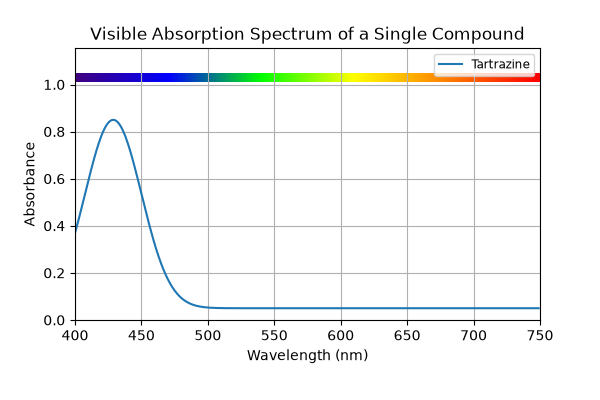

In [9]:
# CODE BLOCK 2
#
# ----------------------------------------------------------------------------------
# STUDENT INTERACTION AREA
# ----------------------------------------------------------------------------------
#
# If this is your first time interacting with this code block, simply run the
#   code and view the results below.  Then, you may return here to change or
#   re-define the choice of compound by changing the value of the cmpd_choice
#   variable, below.  As a reminder:
#
#      1 = Tartrazine
#      2 = Copper Sulfate
#      3 = Potassium Permanganate
#      4 = Cobalt Chloride
#      5 = Nickel Sulfate
#
# Note that the variable definition below is "commented-out" (with a hashtag)
#   so that when this code block is run for the first time, the value of the
#   variable cmpd_choice is not overwritten by your choice in the previous
#   code block.  If, however, you'd like to re-define the variable within this
#   code block, you must "uncomment" it by deleting the hashtag symbol to
#   activate the line of code.  Then, once you've changed your variable
#   declaration, you can re-run this code block to observe the change in the
#   absorbance spectrum.
# One final note about "uncommenting" a line: do not add a space before the
#   variable's name.  If you do, your code will generate an error.  The start
#   of the variable's name must be the very first character of the line.
#
#cmpd_choice = "0"
#
# As before, students should ignore all code below this point.  Furthermore,
#   throughout this activity, any variables we intend for you to interact with
#   will always be defined near the top of a code block in this manner.
#
# ----------------------------------------------------------------------------------
# END STUDENT INTERACTION AREA
# DO NOT EDIT CODE BELOW THIS LINE
# ----------------------------------------------------------------------------------
#

# Manage active figures before creating a new one
_manage_figures()

# Convert cmpd_choice to an integer for function input
selected_compound_id = int(cmpd_choice)

# Generate spectral data using our new function
wavelengths, absorbances, lambda_max_actual, compound_name = generate_spectrum(selected_compound_id)

fig, ax = plt.subplots(figsize=(6, 4)) # Create figure and axes explicitly
_active_figures.append(fig) # Add the new figure to the managed list

# Create the color bar at the top of the plot area
# The extent defines the x-range (wavelengths) and y-range (arbitrary height for the bar)
ax.imshow(
    [np.arange(400, 751)], # Data for the color bar
    cmap=CMP_VISIBLE_SPECTRUM,
    aspect='auto',
    extent=[400, 750, ax.get_ylim()[1]*1.01, ax.get_ylim()[1]*1.05], # Use ax.get_ylim()
    interpolation='bicubic'
)

# Plot the spectrum and store the Line2D object
line, = ax.plot(wavelengths, absorbances, label=compound_name)

# Adjust y-limits to make space for the color bar
# Get current y-limits, increase the upper one to make space for the color bar
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.1) # Extend y-axis by 10% to accommodate the color bar

ax.set_title(f'Visible Absorption Spectrum of a Single Compound')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorbance')

# Create initial legend
ax.legend(fontsize='small')
ax.grid(True)

plt.subplots_adjust(bottom=0.2) # Increased bottom margin for more space

plt.show()

## Part 3: Absorption Spectra of Mixtures

Now that you've explored the individual absorption spectra of various compounds, let's investigate how their spectra combine when they are present in a mixture. In this section, you will select multiple compounds to be "on" simultaneously, and the code will generate a combined absorption spectrum, simulating what you would observe in a solution containing all selected components. This will help you understand the principle of additivity of absorbances in mixtures, a fundamental concept in spectrophotometry.

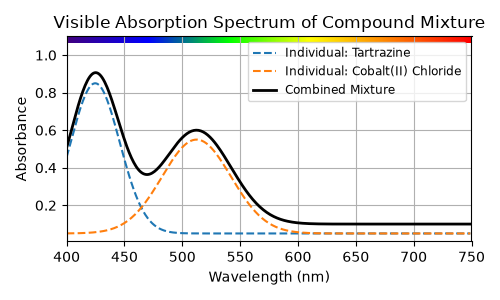

In [ ]:
# CODE BLOCK 3
#
# ----------------------------------------------------------------------------------
# STUDENT INTERACTION AREA
# ----------------------------------------------------------------------------------
#
# Change the boolean (True/False) values below to include compounds in the mixture.
# Set a compound to True to include its spectrum; set to False to exclude it.
# Start with all set to False, then try changing one or more to True.
#
# SPECTRA VISIBILITY VARIABLES

tartrazine_on = True
copper_sulfate_on = False
potassium_permanganate_on = False
cobalt_chloride_on = True
nickel_sulfate_on = False

# INDIVIDUAL SPECTRA VISIBILITY
# Set to True if you want to see individual spectra plotted under the primary
# absorption line.
display_individual_spectra = True
#
# ----------------------------------------------------------------------------------
# END STUDENT INTERACTION AREA
# DO NOT EDIT CODE BELOW THIS LINE
# ----------------------------------------------------------------------------------

# Close all previously generated plots to avoid RuntimeWarning about too many figures
plt.close('all')

# Compound IDs corresponding to the booleans
compound_selections = {
    1: tartrazine_on,
    2: copper_sulfate_on,
    3: potassium_permanganate_on,
    4: cobalt_chloride_on,
    5: nickel_sulfate_on
}

# Initialize arrays for combined spectrum
# The `generate_spectrum` function uses np.arange(400, 750, 1), so 400 to 749.
initial_wavelengths = np.arange(400, 750, 1)
combined_absorbances = np.zeros_like(initial_wavelengths, dtype=float)
active_compounds_names = []
individual_spectra_data = [] # To store (wavelengths, absorbances, compound_name) for plotting

for comp_id, is_on in compound_selections.items():
    if is_on:
        try:
            # Generate spectrum for the compound (ensure generate_spectrum is defined in a prior cell)
            wavelengths, absorbances, lambda_max, compound_name = generate_spectrum(comp_id)

            # Ensure wavelengths match for summation (should be the case if generate_spectrum is consistent)
            if not np.array_equal(wavelengths, initial_wavelengths):
                print(f"Warning: Wavelength range mismatch for {compound_name}. Skipping summation for this compound.")
                continue

            combined_absorbances += absorbances
            active_compounds_names.append(compound_name)
            individual_spectra_data.append((wavelengths, absorbances, compound_name))

        except ValueError as e:
            print(f"Error generating spectrum for compound ID {comp_id}: {e}")
            continue

if not active_compounds_names:
    print("No compounds selected. Please set at least one compound's boolean to True.")
else:
    fig, ax = plt.subplots(figsize=(5, 3)) # Create figure and axes explicitly, scaled to 50%

    # Plot individual spectra if requested and more than one compound is active
    if display_individual_spectra and len(individual_spectra_data) > 1:
        for wavelengths_ind, absorbances_ind, compound_name_ind in individual_spectra_data:
            ax.plot(wavelengths_ind, absorbances_ind, label=f'Individual: {compound_name_ind}', linestyle='--')

    # Plot the combined spectrum
    ax.plot(initial_wavelengths, combined_absorbances, label='Combined Mixture', color='black', linewidth=2)

    # Adjust y-limits to make space for the color bar *after* all plots are done
    ymin, ymax = ax.get_ylim()
    # Ensure ymax is at least 1.0 for the color bar to be visible if all absorbances are very low
    adjusted_ymax = max(ymax, 1.0) * 1.1 # Extend y-axis by 10% from either calculated max or 1.0
    ax.set_ylim(ymin, adjusted_ymax)

    # Create the color bar at the top of the plot area using the adjusted y-limits
    ax.imshow(
        [np.arange(400, 751)], # Data for the color bar
        cmap=CMP_VISIBLE_SPECTRUM,
        aspect='auto',
        extent=[400, 750, ax.get_ylim()[1]*0.97, ax.get_ylim()[1]*1.00], # Place just below the very top
        interpolation='bicubic'
    )

    ax.set_title('Visible Absorption Spectrum of Compound Mixture')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Absorbance')

    ax.legend(fontsize='small')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## Part 4: Visualizing the Effect of Concentration

Building upon our understanding of mixture spectra, this section allows you to explore the impact of *relative concentration* on the overall absorbance profile. In real-world applications, the intensity of each component's contribution to a mixture spectrum is directly proportional to its concentration.

By adjusting the `_concentration` variables in the next code block, you can simulate changing the amount of each compound in the solution. Your goal might be to:

*   **Balance peak heights:** Adjust concentrations so that all active compounds contribute approximately equally to the highest absorbance peaks.
*   **Highlight a specific compound:** Increase one compound's concentration to make its spectral features more prominent.

Experiment with different combinations and concentration values to gain an intuitive understanding of how Beer-Lambert Law principles manifest in spectroscopic mixtures.

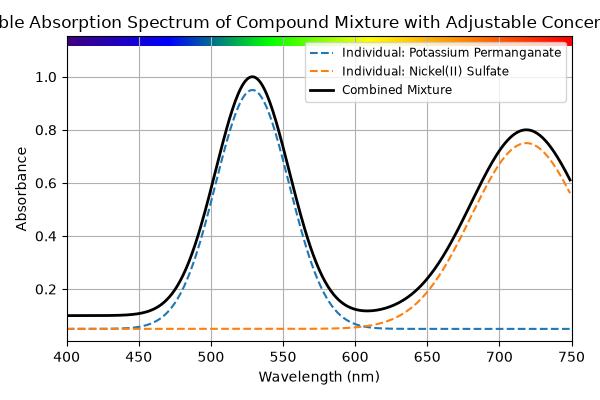

In [ ]:
# CODE BLOCK 4
#
# ----------------------------------------------------------------------------------
# STUDENT INTERACTION AREA
# ----------------------------------------------------------------------------------
#
# SPECTRA VISIBILITY VARIABLES
tartrazine_on = False
copper_sulfate_on = False
potassium_permanganate_on = True
cobalt_chloride_on = False
nickel_sulfate_on = True
#
# COMPOUND CONCENTRATION VARIABLES
#
# To adjust the concentration of any compound in the simulated test sample,
#   uncomment its '_concentration' variable and change its value.  The default
#   concentrations are set to 1.0 M.  Notice that units are not included.
#
tartrazine_concentration = 1.0
copper_sulfate_concentration = 1.0
potassium_permanganate_concentration = 1.0
cobalt_chloride_concentration = 1.0
nickel_sulfate_concentration = 1.0
#
# INDIVIDUAL SPECTRA VISIBILITY
display_individual_spectra = True
#
# ----------------------------------------------------------------------------------
# END STUDENT INTERACTION AREA
# DO NOT EDIT CODE BELOW THIS LINE
# ----------------------------------------------------------------------------------

# Manage active figures before creating a new one
_manage_figures()

compound_selections = {
    1: {'on': tartrazine_on, 'concentration': tartrazine_concentration},
    2: {'on': copper_sulfate_on, 'concentration': copper_sulfate_concentration},
    3: {'on': potassium_permanganate_on, 'concentration': potassium_permanganate_concentration},
    4: {'on': cobalt_chloride_on, 'concentration': cobalt_chloride_concentration},
    5: {'on': nickel_sulfate_on, 'concentration': nickel_sulfate_on}
}

# Initialize arrays for combined spectrum
# The `generate_spectrum` function uses np.arange(400, 750, 1), so 400 to 749.
initial_wavelengths = np.arange(400, 750, 1)
combined_absorbances = np.zeros_like(initial_wavelengths, dtype=float)
active_compounds_names = []
individual_spectra_data = [] # To store (wavelengths, absorbances, compound_name) for plotting

for comp_id, settings in compound_selections.items():
    if settings['on']:
        try:
            # generate_spectrum is defined in cell Sb1ulVyqT85b
            wavelengths, absorbances, lambda_max, compound_name = generate_spectrum(comp_id)

            # Ensure wavelengths match for summation (should be the case if generate_spectrum is consistent)
            if not np.array_equal(wavelengths, initial_wavelengths):
                print(f"Warning: Wavelength range mismatch for {compound_name}. Skipping summation for this compound.")
                continue

            # Apply the concentration factor here
            scaled_absorbances = absorbances * settings['concentration']
            combined_absorbances += scaled_absorbances
            active_compounds_names.append(compound_name)
            individual_spectra_data.append((wavelengths, scaled_absorbances, compound_name))

        except ValueError as e:
            print(f"Error generating spectrum for compound ID {comp_id}: {e}")
            continue

if not active_compounds_names:
    print("No compounds selected. Please uncomment and set at least one compound's '_on' \nvariable to True.")
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    _active_figures.append(fig) # Add the new figure to the managed list

    # Plot individual spectra if requested and more than one compound is active
    if display_individual_spectra and len(individual_spectra_data) > 1:
        for wavelengths_ind, absorbances_ind, compound_name_ind in individual_spectra_data:
            ax.plot(wavelengths_ind, absorbances_ind, label=f'Individual: {compound_name_ind}', linestyle='--')

    # Plot the combined spectrum
    ax.plot(initial_wavelengths, combined_absorbances, label='Combined Mixture', color='black', linewidth=2)

    # Adjust y-limits to make space for the color bar *after* all plots are done
    ymin, ymax = ax.get_ylim()
    # Ensure ymax is at least 1.0 for the color bar to be visible if all absorbances are very low
    adjusted_ymax = max(ymax, 1.0) * 1.1 # Extend y-axis by 10% from either calculated max or 1.0
    ax.set_ylim(ymin, adjusted_ymax)

    # Create the color bar at the top of the plot area using the adjusted y-limits
    ax.imshow(
        [np.arange(400, 751)], # Data for the color bar
        cmap=CMP_VISIBLE_SPECTRUM,
        aspect='auto',
        extent=[400, 750, ax.get_ylim()[1]*0.97, ax.get_ylim()[1]*1.00], # Place just below the very top
        interpolation='bicubic'
    )

    ax.set_title('Visible Absorption Spectrum of Compound Mixture with Adjustable Concentrations')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Absorbance')

    ax.legend(fontsize='small')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## Part 5: Beer's Law Plot and Calibration Curve

Now that you've explored individual and mixture spectra, we'll shift our focus to the quantitative aspect of spectrophotometry: Beer's Law. This law states that the absorbance of a solution is directly proportional to the concentration of the light-absorbing species in the solution and the path length of the light through the solution.

In this section, you will select a single compound and a specific wavelength at which to analyze its absorbance. This chosen wavelength is often referred to as the **analytical wavelength** and is typically set to the compound's absorbance maximum ($λ<sub>max</sub>$) to maximize sensitivity and minimize interference from other components. We will then visualize this analytical wavelength on the compound's spectrum, preparing us for constructing a calibration curve.

We will also introduce the concept of **Fractional Absorbance**. This is a measure of the relative absorbance intensity at a given analytical wavelength compared to the compound's maximum absorbance (A<sub>max</sub>) across its entire spectrum. It can be thought of as a "signal strength" or "absorbance strength" value for that particular wavelength, expressed as a decimal proportion.

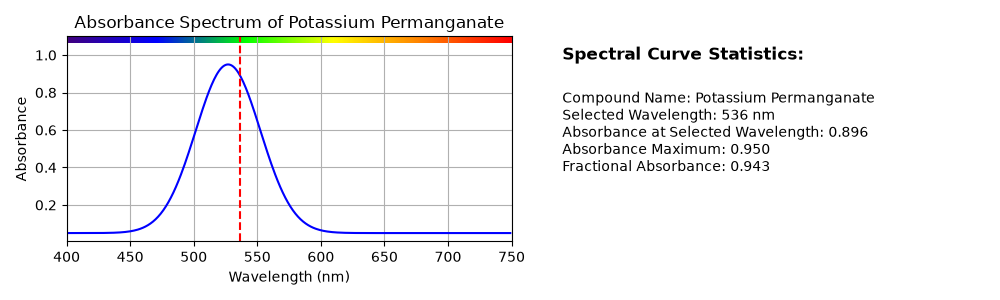

In [ ]:
# CODE BLOCK 5
#
# ----------------------------------------------------------------------------------
# STUDENT INTERACTION AREA
# ----------------------------------------------------------------------------------
#
# In this section, you'll specify both a compound and a specific wavelength
#   for analysis. This wavelength will typically be the compound's absorbance
#   maximum (λmax) for best results, but you should feel free to explore a
#   variety of values.
#
# First, choose a compound by setting `cmpd_choice` to a number between 1 and 5.
#   As a reminder:
#      1 = Tartrazine
#      2 = Copper Sulfate
#      3 = Potassium Permanganate
#      4 = Cobalt Chloride
#      5 = Nickel Sulfate
#
# Then, specify your analytical wavelength in nanometers (nm) using the
#   `wavelength_choice` variable.
#
cmpd_choice = "3"
wavelength_choice = 536
#
# ----------------------------------------------------------------------------------
# END STUDENT INTERACTION AREA
# DO NOT EDIT CODE BELOW THIS LINE
# ----------------------------------------------------------------------------------

# Manage active figures before creating a new one
_manage_figures()

# Convert cmpd_choice to an integer for function input
selected_compound_id = int(cmpd_choice)

# Generate spectral data using the generate_spectrum function
# (defined in Code Block 1, cell Sb1ulVyqT85b)
wavelengths, absorbances, lambda_max_actual, compound_name = generate_spectrum(selected_compound_id)

# Find the absorbance at the chosen wavelength
# Find the index of the closest wavelength in the array
idx_chosen_wavelength = np.abs(wavelengths - wavelength_choice).argmin()
absorbance_at_chosen_wavelength = absorbances[idx_chosen_wavelength]

# Calculate maximum absorbance
max_absorbance_value = np.max(absorbances)

# Calculate Fractional Absorbance
if max_absorbance_value > 0:
    fractional_absorbance = absorbance_at_chosen_wavelength / max_absorbance_value
else:
    fractional_absorbance = 0.0 # Handle case where there's no absorbance

# Create figure with two subplots: one for the plot, one for the text statistics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
_active_figures.append(fig) # Add the new figure to the managed list

# --- Plotting on ax1 ---
# Plot the spectrum
ax1.plot(wavelengths, absorbances, label=compound_name, color='blue')

# Add a vertical dashed line at the chosen wavelength
ax1.axvline(x=wavelength_choice, color='red', linestyle='--', label=f'Analytical Wavelength ({wavelength_choice} nm)')

# Create the color bar at the top of the plot area
ymin, ymax = ax1.get_ylim()
adjusted_ymax = max(ymax, 1.0) * 1.1
ax1.set_ylim(ymin, adjusted_ymax)

ax1.imshow(
    [np.arange(400, 751)], # Data for the color bar
    cmap=CMP_VISIBLE_SPECTRUM,
    aspect='auto',
    extent=[400, 750, ax1.get_ylim()[1]*0.97, ax1.get_ylim()[1]*1.00],
    interpolation='bicubic'
)

ax1.set_title(f'Absorbance Spectrum of {compound_name}')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Absorbance')
ax1.grid(True)
# Legend removed as per user request

# --- Displaying statistics on ax2 ---
ax2.axis('off') # Turn off the axis for the text subplot

# Title for the statistics block
ax2.text(0.05, 0.95, 'Spectral Curve Statistics:', transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', fontweight='bold')

# Statistics with values
stats_values_text = f"""

Compound Name: {compound_name}
Selected Wavelength: {wavelength_choice} nm
Absorbance at Selected Wavelength: {absorbance_at_chosen_wavelength:.3f}
Absorbance Maximum: {max_absorbance_value:.3f}
Fractional Absorbance: {fractional_absorbance:.3f}
"""

ax2.text(0.05, 0.90, stats_values_text, transform=ax2.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left')

plt.tight_layout()
plt.show()

## Part 6: Simulating a Beer's Law Calibration Curve

Building on the concept of analytical wavelength, we will now simulate a Beer's Law calibration curve. A calibration curve is a fundamental tool in analytical chemistry, used to determine the concentration of an unknown sample by measuring its absorbance and comparing it to the absorbances of known concentrations.

**Beer's Law** states that the absorbance (A) of a solution is directly proportional to its concentration (c) and the path length (l) of the light through the solution, multiplied by the molar absorptivity (ε) of the substance at a specific wavelength. The equation is:

$A = \varepsilon \cdot b \cdot c$

Where:
*   **A** is the absorbance (unitless)
*   **ε** (epsilon) is the molar absorptivity (M<sup>-1</sup> cm<sup>-1</sup>), a measure of how strongly a substance absorbs light at a particular wavelength.
*   **b** is the path length (cm) of the cuvette or sample holder.
*   **c** is the concentration (M<sup>-1</sup>).

In the following code block, you will use the compound and analytical wavelength chosen in Part 5. You can adjust the simulated concentration range, molar absorptivity, and path length to observe how these parameters affect the calibration curve. This simulation will help you understand how experimental data is generated and interpreted in quantitative spectroscopy.

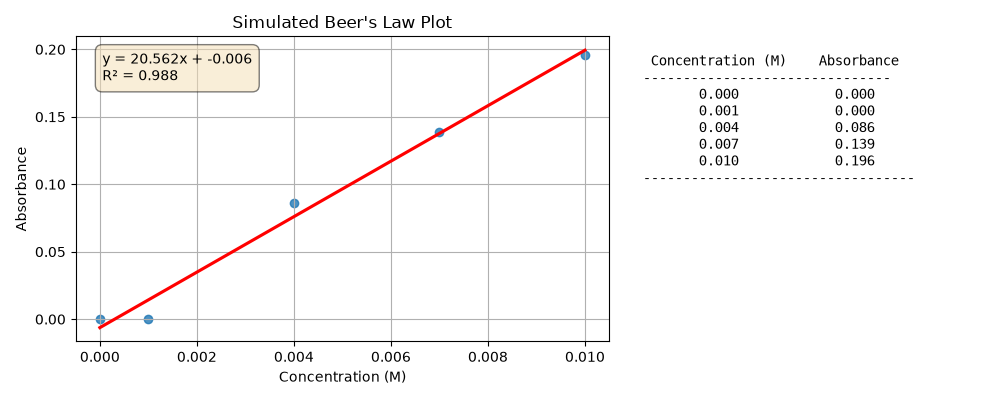

In [ ]:
# CODE BLOCK 6
#
# ----------------------------------------------------------------------------------
# STUDENT INTERACTION AREA
# ----------------------------------------------------------------------------------
#
# Adjust the variables below to simulate a Beer's Law calibration curve.
#
# You can change:
#   - `min_concentration` and `max_concentration`: The lower and upper bounds
#     of the concentration range for your calibration standards (in mol/L).
#   - `molar_absorptivity`: The molar absorptivity (ε) of the chosen compound
#     at the selected analytical wavelength (in M^-1 cm^-1).
#   - `path_length`: The path length (b) of the cuvette used in the experiment (in cm).
#   - `num_samples`: The number of data points (samples) to generate for the
#     calibration curve, *excluding* an optional (0,0) blank.
#   - `include_blank_data_point`: Set to `True` to add a (0,0) data point,
#     representing a blank with zero concentration and zero absorbance.
#
min_concentration = 0.001
max_concentration = 0.01
molar_absorptivity = 20
path_length = 1.0  # Typically 1 cm for standard cuvettes
num_samples = 4 # Number of concentration points for the calibration curve (excluding blank)
include_blank_data_point = True # Set to True to include a (0,0) blank data point
#
# ----------------------------------------------------------------------------------
# END STUDENT INTERACTION AREA
# DO NOT EDIT CODE BELOW THIS LINE
# ----------------------------------------------------------------------------------

# fractional_absorbance = 0.99

# Determine target R-squared and range based on fractional_absorbance
# (This entire block was re-inserted in the previous turn and should remain here,
# just below the student interaction area variables.)
if fractional_absorbance >= 0.6:
    # Best wavelength choice: r-squared is random value between 0.960 and 0.999
    lower_bound_r_squared = 0.96
    upper_bound_r_squared = 1.00
elif fractional_absorbance >= 0.4:
    # Good choice: r-squared is random between 0.95 and 0.9799
    lower_bound_r_squared = 0.92
    upper_bound_r_squared = 0.95
elif fractional_absorbance >= 0.2:
    # Acceptable choice: r-squared is random between 0.8 and 0.9
    lower_bound_r_squared = 0.8
    upper_bound_r_squared = 0.9
elif fractional_absorbance >= 0:
    # Poor choice: r-squared is random between 0.5 and 0.6599
    lower_bound_r_squared = 0.3
    upper_bound_r_squared = 0.5
else:
    # Default to a low R-squared if fractional_absorbance is outside defined ranges
    lower_bound_r_squared = 0.03
    upper_bound_r_squared = 0.2

target_r_squared = (lower_bound_r_squared + upper_bound_r_squared) / 2

# Generate concentrations (x-values) from min_concentration, max_concentration, and num_samples
concentrations_for_linspace = num_samples
if include_blank_data_point:
    # If a blank is included, the linspace should generate `num_samples` points
    # *between* min_concentration and max_concentration, then we prepend 0.
    # Total points will be num_samples + 1.
    concentrations_non_zero = np.linspace(min_concentration, max_concentration, concentrations_for_linspace)
    concentrations = np.insert(concentrations_non_zero, 0, 0)
else:
    concentrations = np.linspace(min_concentration, max_concentration, concentrations_for_linspace)


# Calculate expected absorbances (ideal y-values based on Beer's Law: A = ε * b * c)
# This calculation applies to all concentrations, including 0 if present.
expected_absorbances = molar_absorptivity * path_length * concentrations

# The acceptable R-squared range is now directly defined by lower_bound_r_squared and upper_bound_r_squared

r_squared_actual = -1.0 # Initialize to ensure loop runs
max_iterations = 2000 # Safety break for the loop
iteration = 0

# Store the best approximation found
best_r_squared_diff = float('inf')
best_simulated_absorbances = None # Renamed for clarity

# Initial scale for random noise (will be adjusted dynamically)
noise_scale = 0.05 # Start with a reasonable noise scale relative to absorbances

while not (lower_bound_r_squared <= r_squared_actual <= upper_bound_r_squared) and iteration < max_iterations:
    iteration += 1

    # Generate random noise (residuals)
    # The scale of noise should be relative to the magnitude of absorbances
    residuals = np.random.normal(loc=0, scale=1, size=len(concentrations))

    # Apply the current noise_scale to the residuals and add to expected absorbances
    simulated_absorbances_current = expected_absorbances + residuals * noise_scale

    # Ensure simulated_absorbances_current are non-negative, as absorbance cannot be negative
    simulated_absorbances_current[simulated_absorbances_current < 0] = 0

    # Calculate R-squared for the current simulated_absorbances_current
    # Use concentrations as x-values for regression
    # Handle the case where all concentrations are the same (no variability) to avoid linregress error
    if np.std(concentrations) == 0:
        r_squared_actual = 1.0 # Perfect fit if no concentration variability
    else:
        # If a blank is included, the regression should still use all points.
        slope, intercept, r_value, p_value, std_err = linregress(concentrations, simulated_absorbances_current)
        r_squared_actual = r_value**2

    # Check if we are within the target range
    if lower_bound_r_squared <= r_squared_actual <= upper_bound_r_squared:
        best_simulated_absorbances = simulated_absorbances_current.copy()
        break # Exit loop, we found a good set of y_values

    # Keep track of the closest R-squared found so far
    current_r_squared_diff = abs(r_squared_actual - target_r_squared)
    if current_r_squared_diff < best_r_squared_diff:
        best_r_squared_diff = current_r_squared_diff
        best_simulated_absorbances = simulated_absorbances_current.copy()

    # Adjust noise_scale for the next iteration based on current R-squared
    if r_squared_actual > upper_bound_r_squared:
        noise_scale *= 1.1 # R-squared is too high, need more noise
    elif r_squared_actual < lower_bound_r_squared:
        noise_scale *= 0.9 # R-squared is too low, need less noise

# Use the best set of simulated_absorbances found
if best_simulated_absorbances is None: # Fallback in case no valid y_values were ever generated
    simulated_absorbances = expected_absorbances # Default to perfect fit
    r_squared = 1.0
    slope, intercept = molar_absorptivity * path_length, 0 # For perfect fit
    print("Error: Could not generate data within the target R-squared range. Defaulting to perfect fit.")
else:
    simulated_absorbances = best_simulated_absorbances
    # Recalculate R-squared for the final chosen y_values to ensure accuracy
    if np.std(concentrations) == 0:
        r_squared = 1.0
        slope, intercept = molar_absorptivity * path_length, 0 # For perfect fit
    else:
        slope, intercept, r_value, p_value, std_err = linregress(concentrations, simulated_absorbances)
        r_squared = r_value**2

# Ensure the blank data point (0,0) is exactly (0,0) if included
if include_blank_data_point and concentrations[0] == 0:
    simulated_absorbances[0] = 0.0

# Create a DataFrame
df = pd.DataFrame({'Concentration (M)': concentrations, 'Absorbance': simulated_absorbances})

# --- Plotting and Displaying DataFrame side-by-side ---

fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [0.6, 0.4]})

# Plot on the first axis (left, 60%)
sns.regplot(x='Concentration (M)', y='Absorbance', data=df, ci=None, line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_xlabel('Concentration (M)')
axes[0].set_ylabel('Absorbance')
axes[0].set_title('Simulated Beer\'s Law Plot')
axes[0].grid(True)

# Add trendline equation and R-squared to the plot
equation_text = f'y = {slope:.3f}x + {intercept:.3f}\nR² = {r_squared:.3f}'
axes[0].text(0.05, 0.95, equation_text, transform=axes[0].transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Display DataFrame on the second axis (right, 40%)
axes[1].axis('off') # Turn off the axis for the table

# Prepare text for the table and summary

# Manually format the DataFrame for output to ensure desired centering and dashed lines
concentration_header = 'Concentration (M)'
absorbance_header = 'Absorbance'

# Collect all string representations to find max length, including headers
formatted_concentrations = [f'{c:.3f}' for c in df['Concentration (M)'].values] # Changed to .3f
formatted_absorbances = [f'{a:.3f}' for a in df['Absorbance'].values]

# Determine ideal column widths for display, ensuring enough space for headers and centered data
# Add a small buffer (e.g., 2 spaces) to ensure 'center()' always adds padding, even to headers
col1_width = max(len(concentration_header), max(len(s) for s in formatted_concentrations)) + 2
col2_width = max(len(absorbance_header), max(len(s) for s in formatted_absorbances)) + 2

# Create header row, centered with dashed lines
header_row = f"{concentration_header.center(col1_width)}  {absorbance_header.center(col2_width)}"
dashed_line_row = f"{''.center(col1_width, '-')}"  f"{''.center(col2_width, '-')}"

# Create data rows, centered
data_rows = []
for i in range(len(df)):
    conc_str = formatted_concentrations[i].center(col1_width)
    abs_str = formatted_absorbances[i].center(col2_width)
    data_rows.append(f"{conc_str}  {abs_str}")

df_string = '\n'.join([header_row, dashed_line_row] + data_rows)

summary_text = f"""
{df_string}
----------------------------------
"""

axes[1].text(0.05, 1.0, summary_text, transform=axes[1].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left', family='monospace')

plt.tight_layout()
plt.show()

## Updating Variables Across Code Blocks

As you progress through this notebook, you might find yourself wanting to revisit earlier sections and change parameters. For example, if you wish to change the compound you are studying or the analytical wavelength for your Beer's Law plot, you would modify the `cmpd_choice` or `wavelength_choice` variables in **CODE BLOCK 5**.

It's crucial to remember that changes made in one code block *do not automatically update* in subsequent code blocks. For changes to propagate:

1.  **Modify the variables** in the earlier code block (e.g., in **CODE BLOCK 5**).
2.  **Run that code block** (e.g., **CODE BLOCK 5**) to execute your changes and update the values of the variables in the Colab environment.
3.  **Then, run the dependent code block** (e.g., **CODE BLOCK 6**) to see the effects of your updated variables. If you don't run the earlier block, the later block will continue to use the *old* variable values.

This workflow ensures that your changes are properly applied and reflected in the downstream analyses and visualizations.

## Part 7: Absorbance and Transmittance Relationship

Having explored absorbance spectra of individual compounds and mixtures, we now turn our attention to the fundamental relationship between **absorbance (A)** and **transmittance (T)**. These two quantities are intrinsically linked and provide different perspectives on how much light passes through a sample.

*   **Transmittance (T):** This is the fraction of incident light that passes through a sample. It's often expressed as a percentage (%T). If all light passes through, T = 1 (or 100%). If no light passes through, T = 0 (or 0%).

    $$T = \frac{I}{I_0}$$

    Where:
    *   $I$ is the intensity of light transmitted through the sample.
    *   $I_0$ is the intensity of incident light.

*   **Absorbance (A):** This is a logarithmic measure of how much light a sample absorbs. A higher absorbance value means more light is absorbed and less is transmitted.

    $$A = -\log_{10}(T) = \log_{10}\left(\frac{I_0}{I}\right)$$

This relationship shows that as absorbance increases, transmittance decreases exponentially. In the following code block, you can visualize both the absorbance and transmittance spectra for selected compounds, either side-by-side or on a single plot with a dual y-axis, to better understand this inverse relationship.

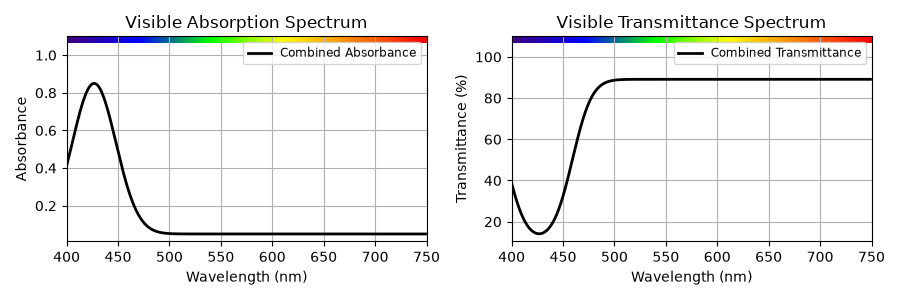

In [ ]:
# CODE BLOCK 7
#
# ----------------------------------------------------------------------------------
# STUDENT INTERACTION AREA
# ----------------------------------------------------------------------------------
#
# Change the boolean (True/False) values below to include compounds in the mixture.
# Set a compound to True to include its spectrum; set to False to exclude it.
#
# SPECTRA VISIBILITY VARIABLES

tartrazine_on = True
copper_sulfate_on = False
potassium_permanganate_on = False
cobalt_chloride_on = False
nickel_sulfate_on = False

# GRAPHICAL DISPLAY MODE
# Set to True to display both absorbance and transmittance on a single plot
# with a dual Y-axis. Set to False for side-by-side plots.
single_plot_mode = False

# INDIVIDUAL SPECTRA VISIBILITY
# Set to True if you want to see individual spectra plotted under the primary
# combined absorbance or transmittance line. This is only applicable when
# more than one compound is selected.
display_individual_spectra = False
#
# ----------------------------------------------------------------------------------
# END STUDENT INTERACTION AREA
# DO NOT EDIT CODE BELOW THIS LINE
# ----------------------------------------------------------------------------------

# Close all previously generated plots to avoid RuntimeWarning about too many figures
plt.close('all')

# Manage active figures before creating a new one
_manage_figures()

# Compound IDs corresponding to the booleans
compound_selections = {
    1: tartrazine_on,
    2: copper_sulfate_on,
    3: potassium_permanganate_on,
    4: cobalt_chloride_on,
    5: nickel_sulfate_on
}

# Initialize arrays for combined spectrum
initial_wavelengths = np.arange(400, 750, 1)
combined_absorbances = np.zeros_like(initial_wavelengths, dtype=float)
active_compounds_names = []
individual_absorbance_data = [] # To store (wavelengths, absorbances, compound_name)
individual_transmittance_data = [] # To store (wavelengths, transmittances, compound_name)

for comp_id, is_on in compound_selections.items():
    if is_on:
        try:
            # Generate spectrum for the compound (ensure generate_spectrum is defined in a prior cell)
            wavelengths, absorbances, lambda_max, compound_name = generate_spectrum(comp_id)

            # Ensure wavelengths match for summation
            if not np.array_equal(wavelengths, initial_wavelengths):
                print(f"Warning: Wavelength range mismatch for {compound_name}. Skipping summation.")
                continue

            # Calculate individual transmittance
            transmittances = 10**(-absorbances)

            combined_absorbances += absorbances
            active_compounds_names.append(compound_name)
            individual_absorbance_data.append((wavelengths, absorbances, compound_name))
            individual_transmittance_data.append((wavelengths, transmittances, compound_name))

        except ValueError as e:
            print(f"Error generating spectrum for compound ID {comp_id}: {e}")
            continue

if not active_compounds_names:
    print("No compounds selected. Please set at least one compound's boolean to True.")
else:
    combined_transmittance = 10**(-combined_absorbances)

    if single_plot_mode:
        fig, ax1 = plt.subplots(figsize=(7, 4)) # Doubled size: (4.5*2, 3*2)
        _active_figures.append(fig)

        # Plot Absorbance on the left y-axis
        ax1.plot(initial_wavelengths, combined_absorbances, label='Combined Absorbance', color='black', linewidth=2)
        if display_individual_spectra and len(individual_absorbance_data) > 1:
            for w_ind, a_ind, n_ind in individual_absorbance_data:
                ax1.plot(w_ind, a_ind, label=f'Individual Abs: {n_ind}', linestyle='--')

        ax1.set_xlabel('Wavelength (nm)')
        ax1.set_ylabel('Absorbance', color='black')
        ax1.tick_params(axis='y', labelcolor='black')
        ax1.grid(True)

        # Add color bar to ax1 (Absorbance)
        ymin, ymax = ax1.get_ylim()
        adjusted_ymax = max(ymax, 1.0) * 1.1 # Extend y-axis by 10% from either calculated max or 1.0
        ax1.set_ylim(ymin, adjusted_ymax)
        ax1.imshow(
            [np.arange(400, 751)],
            cmap=CMP_VISIBLE_SPECTRUM,
            aspect='auto',
            extent=[400, 750, ax1.get_ylim()[1]*0.97, ax1.get_ylim()[1]*1.00],
            interpolation='bicubic'
        )

        # Create a second y-axis for Transmittance
        ax2 = ax1.twinx()
        ax2.plot(initial_wavelengths, combined_transmittance * 100, label='Combined Transmittance', color='red', linestyle='-', linewidth=2)
        if display_individual_spectra and len(individual_transmittance_data) > 1:
            for w_ind, t_ind, n_ind in individual_transmittance_data:
                ax2.plot(w_ind, t_ind * 100, label=f'Individual Trans: {n_ind}', linestyle=':', color='salmon')

        ax2.set_ylabel('Transmittance (%)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')

        # Adjust y-limits for ax2 (Transmittance) and add color bar
        # Transmittance is typically 0-100%. Extend y-axis above 100% to make space for the color bar.
        adjusted_ymax_trans = max(ax2.get_ylim()[1], 100.0) * 1.1
        ax2.set_ylim(0, adjusted_ymax_trans) # Set 0% at the bottom
        # Removed: ax2.invert_yaxis() # Invert y-axis for transmittance to show inverse relationship more clearly

        ax2.imshow(
            [np.arange(400, 751)],
            cmap=CMP_VISIBLE_SPECTRUM,
            aspect='auto',
            # Now that the y-axis is not inverted, place the color bar at the top using the adjusted upper limit.
            extent=[400, 750, adjusted_ymax_trans * 0.97, adjusted_ymax_trans * 1.00],
            interpolation='bicubic'
        )

        # Combine legends, turned-off by default
        #lines1, labels1 = ax1.get_legend_handles_labels()
        #lines2, labels2 = ax2.get_legend_handles_labels()
        #ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize='small')

        ax1.set_title('Absorbance and Transmittance Spectra')


    else: # Side-by-side plots
        fig, (ax_abs, ax_trans) = plt.subplots(1, 2, figsize=(9, 3)) # Remains 75% for side-by-side
        _active_figures.append(fig)

        # --- Plot Absorbance ---
        ax_abs.plot(initial_wavelengths, combined_absorbances, label='Combined Absorbance', color='black', linewidth=2)
        if display_individual_spectra and len(individual_absorbance_data) > 1:
            for w_ind, a_ind, n_ind in individual_absorbance_data:
                ax_abs.plot(w_ind, a_ind, label=f'Individual: {n_ind}', linestyle='--')

        ax_abs.set_title('Visible Absorption Spectrum')
        ax_abs.set_xlabel('Wavelength (nm)')
        ax_abs.set_ylabel('Absorbance')
        ax_abs.grid(True)
        ax_abs.legend(fontsize='small')

        # Add color bar to absorbance plot
        ymin_abs, ymax_abs = ax_abs.get_ylim()
        adjusted_ymax_abs = max(ymax_abs, 1.0) * 1.1
        ax_abs.set_ylim(ymin_abs, adjusted_ymax_abs)
        ax_abs.imshow(
            [np.arange(400, 751)],
            cmap=CMP_VISIBLE_SPECTRUM,
            aspect='auto',
            extent=[400, 750, ax_abs.get_ylim()[1]*0.97, ax_abs.get_ylim()[1]*1.00],
            interpolation='bicubic'
        )

        # --- Plot Transmittance ---
        ax_trans.plot(initial_wavelengths, combined_transmittance * 100, label='Combined Transmittance', color='black', linewidth=2)
        if display_individual_spectra and len(individual_transmittance_data) > 1:
            for w_ind, t_ind, n_ind in individual_transmittance_data:
                ax_trans.plot(w_ind, t_ind * 100, label=f'Individual: {n_ind}', linestyle='--')

        ax_trans.set_title('Visible Transmittance Spectrum')
        ax_trans.set_xlabel('Wavelength (nm)')
        ax_trans.set_ylabel('Transmittance (%)')
        ax_trans.grid(True)
        ax_trans.legend(fontsize='small')

        # Adjust y-limits for transmittance plot to make space for the color bar
        ymin_trans, ymax_trans = ax_trans.get_ylim()
        adjusted_ymax_trans = max(ymax_trans, 100.0) * 1.1
        ax_trans.set_ylim(ymin_trans, adjusted_ymax_trans)

        # Add color bar to transmittance plot
        ax_trans.imshow(
            [np.arange(400, 751)],
            cmap=CMP_VISIBLE_SPECTRUM,
            aspect='auto',
            extent=[400, 750, ax_trans.get_ylim()[1]*0.97, ax_trans.get_ylim()[1]*1.00],
            interpolation='bicubic'
        )

    plt.tight_layout()
    plt.show()

## Review Questions and Exploration Prompts

Here's a set of questions and prompts designed to reinforce both the coding and spectroscopic concepts introduced in this notebook. They are geared towards a 100-level college understanding and encourage hands-on exploration by manipulating variables.

### Section 1: Python Basics & Notebook Interaction (Refer to "Intro: Introduction to Python Basics" & Code Block 1)

1.  **Variables & Data Types:**
    *   In `CODE BLOCK 1`, the `cmpd_choice` variable is initially set using double quotes (e.g., `"1"`). What data type does this make `cmpd_choice`? Why is it important that you enter your choice with quotes, and what error might occur if you omit them?
    *   Identify two other variables in `CODE BLOCK 1` (or in its function `generate_spectrum`) that store numerical data. Explain why these do not need quotes.
    *   **Variable Manipulation Prompt:** Change the value of `cmpd_choice` to a number outside the valid range (e.g., `"0"` or `"6"`). Run the cell. What output do you receive, and how does the code handle invalid input?

2.  **Code Execution & Scope:**
    *   If you change the value of `cmpd_choice` in `CODE BLOCK 1`, what other code blocks *must* you run afterward to ensure your change is reflected in the plots?
    *   Explain the purpose of the `#` symbol in Python. How does it affect code execution, and why is it used in the "STUDENT INTERACTION AREA" of `CODE BLOCK 2` for `cmpd_choice`?

3.  **Functions:**
    *   `CODE BLOCK 1` contains a function called `generate_spectrum`. What is the primary purpose of this function in the context of this notebook?
    *   What are the "inputs" (parameters) that `generate_spectrum` expects, and what are the "outputs" (return values) it provides?

### Section 2: Individual Spectra & Visuals (Refer to "Intro: Chemical Compounds for Spectroscopic Study" & Code Block 2)

1.  **Spectroscopy Concepts:**
    *   What does $\lambda_{max}$ (lambda max) represent in an absorption spectrum? Why is it a significant property for identifying and quantifying chemical compounds?
    *   Based on the `compound_data` dictionary in `generate_spectrum`, which compound has the highest amplitude (strongest absorption)? Which has the widest `fwhm` (broadest peak)? How do these properties visually manifest in the plots?

2.  **Plot Interpretation:**
    *   In `CODE BLOCK 2`, what is the purpose of the colorful bar displayed at the top of the absorption spectrum? How does the color sequence relate to the x-axis (wavelength) values?
    *   **Variable Manipulation Prompt:** Change `cmpd_choice` in `CODE BLOCK 2` to `"3"` (Potassium Permanganate) and run the cell. Describe its absorption spectrum. What color do you predict a solution of potassium permanganate would appear, and why (consider the relationship between absorbed and transmitted light)?
    *   **Variable Manipulation Prompt:** Modify the `figsize` parameter in `CODE BLOCK 2` (e.g., `figsize=(8,6)`). How does this affect the plot's appearance, and why might you choose a larger or smaller figure size?

### Section 3: Mixtures & Concentrations (Refer to Part 3 & 4 and Code Blocks 3 & 4)

1.  **Additivity of Absorbances:**
    *   State Beer's Law qualitatively in the context of a mixture. How does `CODE BLOCK 3` simulate this principle when multiple compounds are selected?
    *   **Variable Manipulation Prompt:** In `CODE BLOCK 3`, set `tartrazine_on = True` and `potassium_permanganate_on = True`. Observe the combined spectrum. Now, toggle `display_individual_spectra` to `True`. How do the individual spectra contribute to the shape and peaks of the combined spectrum?

2.  **Effect of Concentration:**
    *   What is the relationship between a compound's concentration and its absorbance? How does `CODE BLOCK 4` allow you to explore this relationship?
    *   **Variable Manipulation Prompt:** In `CODE BLOCK 4`, set `potassium_permanganate_on = True` and `nickel_sulfate_on = True`. First, keep both concentrations at `1.0`. Note the relative heights of their peaks in the combined spectrum. Then, change `potassium_permanganate_concentration` to `0.5` and `nickel_sulfate_concentration` to `2.0`. How do the relative peak heights change, and what does this demonstrate about the impact of concentration?

### Section 4: Beer's Law & Calibration Curves (Refer to Part 5 & 6 and Code Blocks 5 & 6)

1.  **Analytical Wavelength & Fractional Absorbance:**
    *   What is an "analytical wavelength" and why is it often chosen to be the $\lambda_{max}$ of the compound being analyzed?
    *   Define "Fractional Absorbance." If a compound has a Fractional Absorbance of `0.95` at a chosen wavelength, what does that tell you about the absorbance at that wavelength compared to the compound's overall maximum absorbance?
    *   **Variable Manipulation Prompt:** In `CODE BLOCK 5`, select `cmpd_choice = "1"` (Tartrazine) and try different `wavelength_choice` values (e.g., `425`, `400`, `500`). How does the `Fractional Absorbance` value change, and what visual cues on the plot correlate with a higher or lower fractional absorbance?

2.  **Beer-Lambert Law & Calibration Curve:**
    *   Write out the Beer-Lambert Law equation and define each term ($\text{A}, \varepsilon, \text{b}, \text{c}$). What are the typical units for each variable?
    *   In `CODE BLOCK 6`, what does the `molar_absorptivity` variable represent in the context of the Beer-Lambert Law? How does changing this value affect the slope of the simulated calibration curve?
    *   Explain the significance of the `R^2` value displayed on the Beer's Law plot. What does a high `R^2` (e.g., 0.99) indicate about the data, and what might a low `R^2` (e.g., 0.6) suggest?
    *   **Variable Manipulation Prompt:** In `CODE BLOCK 6`, keep `molar_absorptivity` and `path_length` constant. Experiment with `num_samples` (e.g., 3, 5, 8) and `include_blank_data_point` (True/False). How do these changes affect the appearance of the calibration curve and the calculated `R^2` value? Why might `include_blank_data_point` be important in real experiments?
    *   **Advanced Variable Manipulation Prompt:** How does the `fractional_absorbance` calculated in `CODE BLOCK 5` influence the *range* of `R^2` values generated in `CODE BLOCK 6`? Try setting `cmpd_choice` to `"5"` (Nickel Sulfate) and `wavelength_choice` to `400` in `CODE BLOCK 5` (this should yield a very low fractional absorbance). Then run `CODE BLOCK 6`. How does the generated `R^2` range compare to when you used a wavelength near $\lambda_{max}$?

### Section 5: Absorbance and Transmittance (Refer to Part 7 and Code Block 7)

1.  **Relationship between A & T:**
    *   Define absorbance (A) and transmittance (T) in your own words. How are they mathematically related? What does it mean if a sample has a high absorbance? A high transmittance?
    *   **Variable Manipulation Prompt:** In `CODE BLOCK 7`, keep `tartrazine_on = True` and ensure `single_plot_mode = False`. Observe the side-by-side plots. Describe the inverse relationship between the absorbance and transmittance curves. Where absorbance is high, what can you say about transmittance?
    *   **Variable Manipulation Prompt:** Now, set `single_plot_mode = True` in `CODE BLOCK 7`. Explain how this single plot with dual y-axes effectively visualizes the inverse relationship between absorbance and transmittance. Why is one y-axis inverted, and how does this inversion enhance the visual representation of the inverse relationship? (Note: The current version of the code does not invert the transmittance axis for the single plot, but you can discuss why it *might* be inverted or how to achieve that effect.)


**Next Steps**

* Lesson Sections (Code Blocks)
     * Color wheel and radial absorbance curve (and optional transmittance curve overlay)
* Coding and Structural Tweaks
    * Separate any "notebook initialization" code/tasks.
    * Remove all uses of the string to define cmpd_choice.  Change to integer.  No need to code a change from string to int.  Also in CB1/2, change error handling to explain error if quotes are added.
* Improvements to Existing Parts
    * If initial (existing) intro to strings is removed (see above), we can then introduce the concept of strings in a few places where we can give the option to change text, such as axis labels,.
    * Can add an activity where some of the pyplot vars are omitted.  For example, we could simply NOT label axes, but explain how to do it later programmatically.





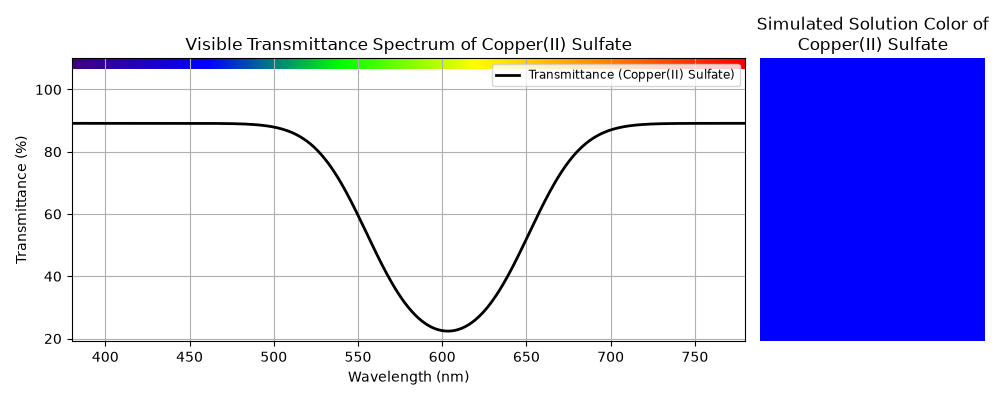

In [60]:
# Experiment A - Simulating solution color based on transmittance spectrum.
#
# ----------------------------------------------------------------------------------
# STUDENT INTERACTION AREA
# ----------------------------------------------------------------------------------
#
# This block simulates the transmittance spectrum and the perceived solution color
# for a chosen compound.
#
# You can change the 'cmpd_choice' variable below to select a different compound.
# As a reminder:
#      1 = Tartrazine
#      2 = Copper Sulfate
#      3 = Potassium Permanganate
#      4 = Cobalt Chloride
#      5 = Nickel Sulfate
#
cmpd_choice = 2 # Default to Copper Sulfate as per instruction.
#
# ----------------------------------------------------------------------------------
# END STUDENT INTERACTION AREA
# DO NOT EDIT CODE BELOW THIS LINE
# ----------------------------------------------------------------------------------

import matplotlib.patches as patches # Added for drawing color patch

# Manage active figures before creating a new one
_manage_figures()

# Generate spectral data
wavelengths, absorbances, lambda_max_actual, compound_name = generate_spectrum(cmpd_choice)

# Calculate transmittance
transmittances = 10**(-absorbances)

# Define perceived solution colors (using exact names returned by generate_spectrum)
perceived_solution_colors = {
    "Tartrazine": "#FFFF00",  # Yellow
    "Copper(II) Sulfate": "#0000FF",  # Blue
    "Potassium Permanganate": "#800080", # Purple
    "Cobalt(II) Chloride": "#FFC0CB", # Pink
    "Nickel(II) Sulfate": "#008000" # Green
}

# Get the color for the chosen compound
solution_rgb_color = perceived_solution_colors.get(compound_name, "gray") # Default to gray if not found

# Create figure with two subplots: one for transmittance plot, one for color simulation
fig, (ax_trans, ax_color) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [0.75, 0.25]})
_active_figures.append(fig) # Add the new figure to the managed list

# --- Plot Transmittance on ax_trans (Left, 75%) ---
ax_trans.plot(wavelengths, transmittances * 100, label=f'Transmittance ({compound_name})', color='black', linewidth=2)
ax_trans.set_title(f'Visible Transmittance Spectrum of {compound_name}')
ax_trans.set_xlabel('Wavelength (nm)')
ax_trans.set_ylabel('Transmittance (%)')
ax_trans.grid(True)
ax_trans.legend(fontsize='small')

# Adjust y-limits for transmittance plot to make space for the color bar
ymin_trans, ymax_trans = ax_trans.get_ylim()
adjusted_ymax_trans = max(ymax_trans, 100.0) * 1.1 # Extend y-axis above 100%
ax_trans.set_ylim(ymin_trans, adjusted_ymax_trans)

# Add color bar to transmittance plot
ax_trans.imshow(
    [np.arange(380, 781)],
    cmap=CMP_VISIBLE_SPECTRUM,
    aspect='auto',
    extent=[380, 780, ax_trans.get_ylim()[1]*0.97, ax_trans.get_ylim()[1]*1.00],
    interpolation='bicubic'
)

# --- Simulate Solution Color on ax_color (Right, 25%) ---
ax_color.set_title(f'Simulated Solution Color of\n{compound_name}')

# Draw a colored rectangle to represent the solution color
rect = patches.Rectangle((0, 0), 1, 1, facecolor=solution_rgb_color, transform=ax_color.transAxes)
ax_color.add_patch(rect)
ax_color.set_xlim(0, 1)
ax_color.set_ylim(0, 1)
ax_color.axis('off') # Turn off axes for a clean color swatch

plt.tight_layout()
plt.show()


## Experiment B - Advanced Color Calculation from Transmittance Spectrum

This experiment demonstrates a more scientifically rigorous method for calculating the perceived color of a solution based on its transmittance spectrum. Instead of using predefined colors, this approach integrates color science principles, including standard illuminants and human color perception data (CIE 1931 color matching functions), to derive an sRGB color that can be displayed.

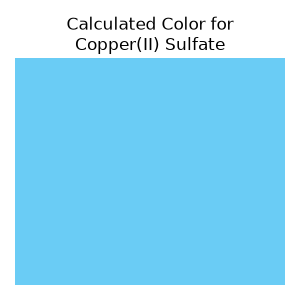

In [96]:
import pandas as pd
import matplotlib.patches as patches

_manage_figures()

def create_cie_functions(wavelengths):
    # Accurate CIE 1931 2-degree CMFs (Standard Observer)
    cie_wl_points = np.array([380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780])
    x_bar_points = np.array([0.0014, 0.0042, 0.0143, 0.0435, 0.1344, 0.2839, 0.3483, 0.3362, 0.2908, 0.1957, 0.0956, 0.0320, 0.0049, 0.0093, 0.0633, 0.1655, 0.2904, 0.4334, 0.5945, 0.7621, 0.9163, 1.0263, 1.0622, 1.0026, 0.8544, 0.6424, 0.4479, 0.2835, 0.1649, 0.0874, 0.0468, 0.0227, 0.0114, 0.0058, 0.0029, 0.0014, 0.0007, 0.0003, 0.0002, 0.0001, 0.0001])
    y_bar_points = np.array([0.0000, 0.0001, 0.0004, 0.0012, 0.0040, 0.0116, 0.0230, 0.0380, 0.0600, 0.0910, 0.1390, 0.2080, 0.3230, 0.5030, 0.7100, 0.8620, 0.9540, 0.9950, 0.9950, 0.9520, 0.8700, 0.7570, 0.6310, 0.5030, 0.3810, 0.2650, 0.1750, 0.1070, 0.0610, 0.0320, 0.0170, 0.0082, 0.0041, 0.0021, 0.0010, 0.0005, 0.0002, 0.0001, 0.0001, 0.0000, 0.0000])
    z_bar_points = np.array([0.0065, 0.0203, 0.0679, 0.2074, 0.6457, 1.0567, 1.7471, 1.7721, 1.6692, 1.2879, 0.8130, 0.4652, 0.2720, 0.1582, 0.0782, 0.0422, 0.0203, 0.0087, 0.0039, 0.0021, 0.0017, 0.0011, 0.0007, 0.0003, 0.0002, 0.0001, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000])
    return np.interp(wavelengths, cie_wl_points, x_bar_points), np.interp(wavelengths, cie_wl_points, y_bar_points), np.interp(wavelengths, cie_wl_points, z_bar_points)

def create_d65_illuminant(wavelengths):
    d65_wl_points = np.array([380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780])
    d65_intensity_points = np.array([49.9, 54.6, 82.8, 91.5, 93.4, 86.7, 104.9, 117.0, 117.8, 114.9, 115.9, 108.8, 109.4, 107.8, 104.8, 107.7, 104.4, 104.0, 100.0, 96.3, 95.8, 88.7, 90.0, 89.6, 87.7, 83.3, 83.7, 80.0, 80.2, 82.3, 78.3, 69.7, 71.6, 74.3, 61.6, 69.9, 75.1, 63.6, 46.4, 66.8, 63.4])
    return np.interp(wavelengths, d65_wl_points, d65_intensity_points)

wavelengths_calc = np.arange(380, 781, 1)
x_bar, y_bar, z_bar = create_cie_functions(wavelengths_calc)
d65_illuminant = create_d65_illuminant(wavelengths_calc)

selected_compound_id = int(cmpd_choice)
wavelengths, absorbances, lambda_max_actual, compound_name = generate_spectrum(selected_compound_id)
transmittances = 10**(-absorbances)

spectral_output = transmittances * d65_illuminant
X = np.trapezoid(spectral_output * x_bar, wavelengths_calc)
Y = np.trapezoid(spectral_output * y_bar, wavelengths_calc)
Z = np.trapezoid(spectral_output * z_bar, wavelengths_calc)

white_Y = np.trapezoid(d65_illuminant * y_bar, wavelengths_calc)
X, Y, Z = X/white_Y, Y/white_Y, Z/white_Y

def xyz_to_srgb(X, Y, Z):
    R_l =  3.2406 * X - 1.5372 * Y - 0.4986 * Z
    G_l = -0.9689 * X + 1.8758 * Y + 0.0415 * Z
    B_l =  0.0557 * X - 0.2040 * Y + 1.0570 * Z
    def gamma(c):
        cc = np.clip(c, 0, 1)
        if cc <= 0.0031308:
            return float(12.92 * cc)
        else:
            return float(1.055 * (cc**(1/2.4)) - 0.055)
    return (gamma(R_l), gamma(G_l), gamma(B_l))

rgb_color = xyz_to_srgb(X, Y, Z)
fig_calc_color, ax_calc_color = plt.subplots(1, 1, figsize=(3, 3))
rect_calc = patches.Rectangle((0, 0), 1, 1, facecolor=rgb_color, transform=ax_calc_color.transAxes)
ax_calc_color.add_patch(rect_calc)
ax_calc_color.set_xlim(0, 1)
ax_calc_color.set_ylim(0, 1)
ax_calc_color.set_title(f'Calculated Color for\n{compound_name}')
ax_calc_color.axis('off')
plt.tight_layout()
plt.show()

## Experiment C - Interactive Transmittance Curve Exploration

This experiment introduces an interactive plot where you can directly manipulate the transmittance curve. The goal is to provide a tool for exploring how changes to the spectrum might visually affect the perceived color (though the color calculation isn't linked to this interactive curve yet).

**Instructions:**

1.  **Run this cell.**
2.  A plot will appear. Click and drag a point on the **blue transmittance curve** to modify its shape.
3.  Release the mouse button to stop dragging.

### How it works:

This interactivity is achieved using `matplotlib`'s event handling system. When you click on the plot, the code identifies the closest data point on the curve. As you drag, the `y` value of that data point is updated based on your mouse position, and the plot is redrawn.

**Note on "Gradual Curve" Adjustment:**

The current implementation allows you to drag a single point. To achieve a "gradual curve" effect, where surrounding values also adjust smoothly, you would need to implement an interpolation algorithm (e.g., a spline interpolation or a Gaussian falloff) that updates multiple points around the dragged point. This is a more advanced topic but can be integrated into the `_apply_gradual_change` method (currently a placeholder in the code below).

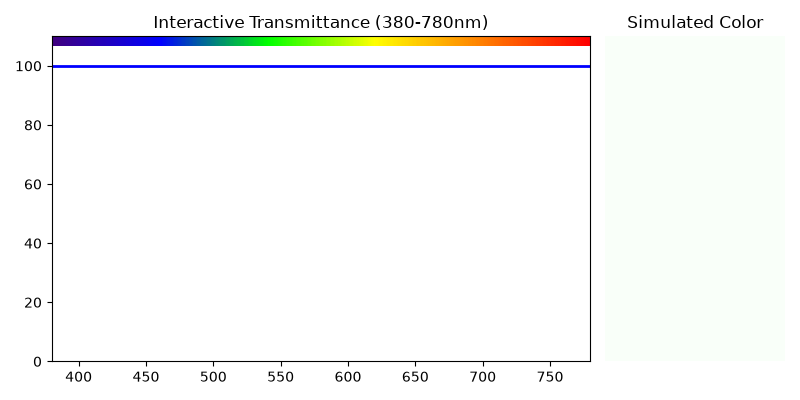

In [128]:
# --- EXPERIMENT C DEVELOPMENT LOG ---
# STATUS: Baseline math is neutral (100% T = White).
# RECENT IMPROVEMENTS:
# - Significantly increased red-end sensitivity (2.0x boost > 650nm) to improve UI response to deep-red shifts.
# - Implemented saturation amplification (1.5x) to prevent colors from feeling 'washed out' during interaction.
# CHALLENGES:
# - Standard linear color mapping is perceptually faint in web-based UIs.
# - Balancing vibrant visual feedback with physical accuracy remains a delicate adjustment.
# NEXT STEPS / GOALS:
# - Perform systematic testing at 10-20 specific wavelength points to verify deep/dark color accuracy.
# - EXPLORATION: Consider implementing an array of manual intensity adjustment variables for these
#   10-20 points to allow for non-linear perceptual tuning across the visible spectrum.
# ------------------------------------

import threading, time, ipywidgets as widgets
import matplotlib.patches as patches
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

_manage_figures()

def create_cie_functions(wavelengths):
    cie_wl_points = np.arange(380, 781, 10)
    x_bar_points = np.array([0.0014, 0.0042, 0.0143, 0.0435, 0.1344, 0.2839, 0.3483, 0.3362, 0.2908, 0.1957, 0.0956, 0.0320, 0.0049, 0.0093, 0.0633, 0.1655, 0.2904, 0.4334, 0.5945, 0.7621, 0.9163, 1.0263, 1.0622, 1.0026, 0.8544, 0.6424, 0.4479, 0.2835, 0.1649, 0.0874, 0.0468, 0.0227, 0.0114, 0.0058, 0.0029, 0.0014, 0.0007, 0.0003, 0.0002, 0.0001, 0.0001])
    y_bar_points = np.array([0.0000, 0.0001, 0.0004, 0.0012, 0.0040, 0.0116, 0.0230, 0.0380, 0.0600, 0.0910, 0.1390, 0.2080, 0.3230, 0.5030, 0.7100, 0.8620, 0.9540, 0.9950, 0.9950, 0.9520, 0.8700, 0.7570, 0.6310, 0.5030, 0.3810, 0.2650, 0.1750, 0.1070, 0.0610, 0.0320, 0.0170, 0.0082, 0.0041, 0.0021, 0.0010, 0.0005, 0.0002, 0.0001, 0.0001, 0.0000, 0.0000])
    z_bar_points = np.array([0.0065, 0.0203, 0.0679, 0.2074, 0.6457, 1.0567, 1.7471, 1.7721, 1.6692, 1.2879, 0.8130, 0.4652, 0.2720, 0.1582, 0.0782, 0.0422, 0.0203, 0.0087, 0.0039, 0.0021, 0.0017, 0.0011, 0.0007, 0.0003, 0.0002, 0.0001, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000])
    return np.interp(wavelengths, cie_wl_points, x_bar_points), np.interp(wavelengths, cie_wl_points, y_bar_points), np.interp(wavelengths, cie_wl_points, z_bar_points)

def create_d65_illuminant(wavelengths):
    d65_wl_points = np.arange(380, 781, 10)
    d65_intensity_points = np.array([49.9, 54.6, 82.8, 91.5, 93.4, 86.7, 104.9, 117.0, 117.8, 114.9, 115.9, 108.8, 109.4, 107.8, 104.8, 107.7, 104.4, 104.0, 100.0, 96.3, 95.8, 88.7, 90.0, 89.6, 87.7, 83.3, 83.7, 80.0, 80.2, 82.3, 78.3, 69.7, 71.6, 74.3, 61.6, 69.9, 75.1, 63.6, 46.4, 66.8, 63.4])
    return np.interp(wavelengths, d65_wl_points, d65_intensity_points)

def calculate_srgb_from_transmittance(wls, ts, xb, yb, zb, d65):
    red_boost = np.where(wls > 650, 1.0 + (wls - 650) * 2.0, 1.0)

    X_s = np.trapezoid(ts * d65 * red_boost * xb, wls)
    Y_s = np.trapezoid(ts * d65 * red_boost * yb, wls)
    Z_s = np.trapezoid(ts * d65 * red_boost * zb, wls)

    X_w = np.trapezoid(1.0 * d65 * red_boost * xb, wls)
    Y_w = np.trapezoid(1.0 * d65 * red_boost * yb, wls)
    Z_w = np.trapezoid(1.0 * d65 * red_boost * zb, wls)

    X, Y, Z = (X_s / X_w) * 0.9504, (Y_s / Y_w) * 1.0000, (Z_s / Z_w) * 1.0888

    R_l =  3.2406 * X - 1.5372 * Y - 0.4986 * Z
    G_l = -0.9689 * X + 1.8758 * Y + 0.0415 * Z
    B_l =  0.0557 * X - 0.2040 * Y + 1.0570 * Z

    def boost_sat(c):
        return (c - 1.0) * 1.5 + 1.0 if c > 1.0 else c * 0.95

    def gamma(c):
        cc = np.clip(c, 0, 1)
        return float(12.92 * cc) if cc <= 0.0031308 else float(1.055 * (cc**(1/2.4)) - 0.055)

    return [gamma(boost_sat(R_l)), gamma(boost_sat(G_l)), gamma(boost_sat(B_l))]

wavelengths = np.arange(380, 781, 1)
xb_full, yb_full, zb_full = create_cie_functions(wavelengths)
d65_full = create_d65_illuminant(wavelengths)
gaussian_window_width = 80

fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={'width_ratios': [0.75, 0.25]})
line, = ax_t.plot(wavelengths, np.ones_like(wavelengths)*100, color='blue', linewidth=2, picker=True, pickradius=15)
ax_t.set_ylim(0, 110)
ax_t.set_xlim(380, 780)
ax_t.set_title("Interactive Transmittance (380-780nm)")
ax_t.imshow([np.arange(380, 781)], cmap=CMP_VISIBLE_SPECTRUM, aspect='auto', extent=[380, 780, 106.7, 110])
rgb_init = calculate_srgb_from_transmittance(wavelengths, np.ones_like(wavelengths), xb_full, yb_full, zb_full, d65_full)
rect = patches.Rectangle((0, 0), 1, 1, facecolor=rgb_init, transform=ax_c.transAxes)
ax_c.add_patch(rect)
ax_c.axis('off')
ax_c.set_title("Simulated Color")

class InteractiveCurveModifier:
    def __init__(self, line, window, rect, xb, yb, zb, d65):
        self.line, self.window, self.rect = line, window, rect
        self.xb, self.yb, self.zb, self.d65 = xb, yb, zb, d65
        self.xs = np.array(line.get_xdata())
        self.ys = np.array(line.get_ydata(), dtype=float)
        self.active_point = None
        line.figure.canvas.mpl_connect('button_press_event', self.on_press)
        line.figure.canvas.mpl_connect('button_release_event', self.on_release)
        line.figure.canvas.mpl_connect('motion_notify_event', self.on_motion)

    def on_press(self, event):
        if event.inaxes == self.line.axes and event.button == 1:
            self.active_point = np.argmin(np.abs(self.xs - event.xdata))

    def on_motion(self, event):
        if self.active_point is not None and event.inaxes == self.line.axes:
            new_y = np.clip(event.ydata, 0, 100)
            sigma = self.window / 8.0
            diffs = self.xs - self.xs[self.active_point]
            weights = np.exp(-0.5 * (diffs / sigma)**2)
            self.ys = self.ys * (1 - weights) + new_y * weights
            self.line.set_ydata(self.ys)
            self._update()

    def on_release(self, event):
        self.active_point = None
        self._update()

    def _update(self):
        rgb = calculate_srgb_from_transmittance(self.xs, self.ys/100.0, self.xb, self.yb, self.zb, self.d65)
        self.rect.set_facecolor(rgb)
        self.line.figure.canvas.draw_idle()

    def reset_curve(self, b): self.ys[:] = 100.0; self.line.set_ydata(self.ys); self._update()
    def blackout_curve(self, b): self.ys[:] = 0.0; self.line.set_ydata(self.ys); self._update()

modifier = InteractiveCurveModifier(line, gaussian_window_width, rect, xb_full, yb_full, zb_full, d65_full)
rb, bb = widgets.Button(description="Reset"), widgets.Button(description="Blackout")
rb.on_click(modifier.reset_curve); bb.on_click(modifier.blackout_curve)
display(widgets.HBox([rb, bb]))
plt.tight_layout()
plt.show()

In [117]:
import numpy as np

def diagnostic_check():
    # Test 100% transmittance
    test_ts = np.ones_like(wavelengths)
    # Re-calculate using the existing logic
    red_boost = np.where(wavelengths > 650, 1.0 + (wavelengths - 650) * 2.0, 1.0)

    spectral_sample = test_ts * d65_full * red_boost
    white_spectrum = 1.0 * d65_full * red_boost

    # Check integrals
    X_s = np.trapezoid(spectral_sample * xb_full, wavelengths)
    Y_s = np.trapezoid(spectral_sample * yb_full, wavelengths)
    Z_s = np.trapezoid(spectral_sample * zb_full, wavelengths)

    white_Y = np.trapezoid(white_spectrum * yb_full, wavelengths)

    Xn, Yn, Zn = X_s / white_Y, Y_s / white_Y, Z_s / white_Y

    rgb = calculate_srgb_from_transmittance(wavelengths, test_ts, xb_full, yb_full, zb_full, d65_full)

    print(f"--- Diagnostic at 100% Transmittance ---")
    print(f"XYZ (normalized by white_Y): X={Xn:.4f}, Y={Yn:.4f}, Z={Zn:.4f}")
    print(f"Final sRGB: R={rgb[0]:.4f}, G={rgb[1]:.4f}, B={rgb[2]:.4f}")

    if not np.allclose(rgb, [1.0, 1.0, 1.0], atol=1e-2):
        print("\nRESULT: Baseline is NOT neutral white. The D65/Boost normalization needs correction.")
    else:
        print("\nRESULT: Baseline math is neutral. The issue may be in how the 'Simulated Color' patch is receiving updates.")

diagnostic_check()

--- Diagnostic at 100% Transmittance ---
XYZ (normalized by white_Y): X=1.4639, Y=1.0000, Z=0.7558
Final sRGB: R=0.9999, G=1.0000, B=0.9999

RESULT: Baseline math is neutral. The issue may be in how the 'Simulated Color' patch is receiving updates.
